In [1]:
import numpy as np
import matplotlib as mpl
mpl.rcParams['font.size'] = 14
import matplotlib.pyplot as plt

from core_collision import (
    run_timestepping,
)
from wisp.diagnostics import (
    compute_gamma,
    plot_initial_velocity_distribution,
    plot_full_f_velocity_distribution,
    plot_delta_f_velocity_distribution,
)

lblSize        = 14
ttlSize        = 16
tickSize       = 12   
lgdSize        = 12
txtSize        = 14 

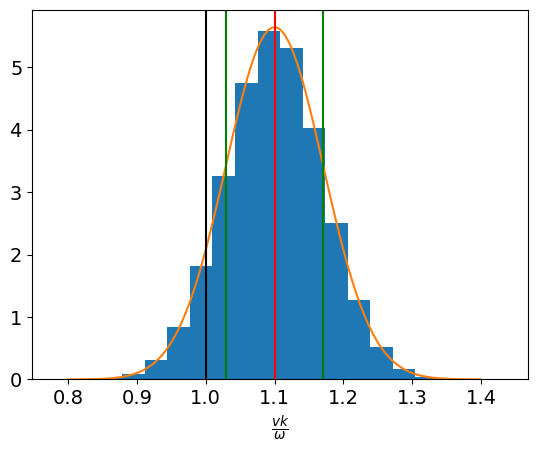

In [2]:
sim_params = {
    "E_c": 1e-8,  # initial E_c (cosine component)
    "E_s": -1e-8,  # initial E_s (sine component)
    "nb_over_ne": 3e-5,  # coupling constant
    "n_steps": 500000,  # number of timesteps, originally 50000
    "dt": 0.1,  # timestep (normalized by wave period)
    "n_particles": 500000,  # number of particles, originally 500000
    "vb": 0.1,  # beam thermal velocity over wave phase velocity
    "ub": 1.1,  # beam flow velocity over wave phase velocity
    "splitting_method": "strang",  # 'strang' or 'trotter'
    "method": "nonlinear",  # 'linear' or 'nonlinear'
    "full_f": False,  # whether to use full distribution function (only for nonlinear)
    "gamma_ratio": 0.9,
    "nu_norm": 2.00,
    "alpha": 0.00,
    "beta": 0.0,
}

fig, ax = plot_initial_velocity_distribution(sim_params)


In [5]:
gamma = compute_gamma(sim_params)
gamma_net = gamma * (1 - sim_params["gamma_ratio"])

print('Predicted linear growth rate: ', gamma)
print('Predicted net growth rate: ', gamma_net)
print('Predicted nonlinear saturated amplitude: ', gamma_net * gamma_net * (3.2 * 3.2))

Predicted linear growth rate:  0.0019561479965198745
Predicted net growth rate:  0.0001956147996519874
Predicted nonlinear saturated amplitude:  3.9183513439116476e-07


In [4]:
nu = '2'
alpha = '0'
beta = '0'
params = nu + '_' + alpha + '_' + beta
sim_outputs = run_timestepping(sim_params)
np.savez('sim_outputs_' + params + '.npz', **sim_outputs)

E_c = sim_outputs["E_c"]
E_s = sim_outputs["E_s"]
x = sim_outputs["x"]
v = sim_outputs["v"]
w = sim_outputs["w"]

Normalized diffusion rate:  2.0
Damping-to-growth ratio:  0.9
Wave damping rate:  0.0017605331968678871
Diffusion rate:  5.988183696135721e-11


Timestepping:   0%|          | 0/500000 [00:00<?, ?step/s]

In [3]:
# Restart here if you want to load the simulation outputs from a file instead of running the simulation again
nu = '2'
alpha = '0'
beta = '0'
params = nu + '_' + alpha + '_' + beta
sim_outputs = np.load(f'sim_outputs_' + params + '.npz')

E_c = sim_outputs["E_c"]
E_s = sim_outputs["E_s"]
x = sim_outputs["x"]
v = sim_outputs["v"]
w = sim_outputs["w"]

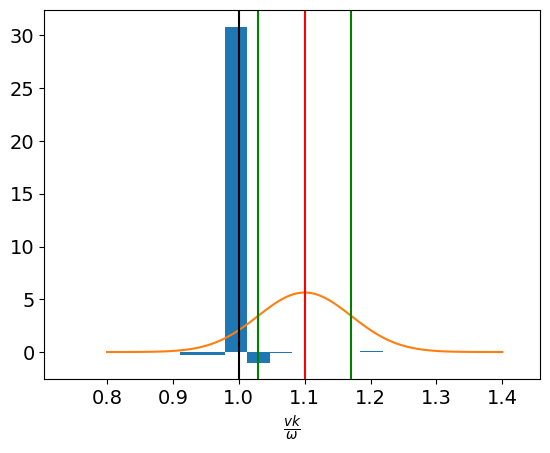

In [4]:
fig, ax = plot_delta_f_velocity_distribution(v, w, sim_params["ub"], sim_params["vb"])

E_c_hist = sim_outputs["E_c_hist"]
E_s_hist = sim_outputs["E_s_hist"]
E_amp_hist = sim_outputs["E_amp_hist"]
phi_hist = sim_outputs["phi_hist"]
time = sim_outputs["time"]

output = [E_c_hist, E_s_hist, E_amp_hist, phi_hist, time]

<function matplotlib.pyplot.savefig(*args, **kwargs) -> 'None'>

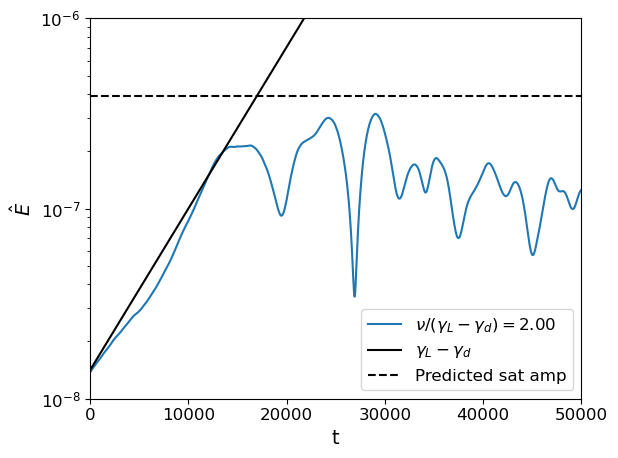

In [6]:
plt.figure()
plt.semilogy(time, np.abs(E_amp_hist), color='tab:blue', label=r'$\nu/(\gamma_L-\gamma_d)=2.00$')
#plt.semilogy(time, np.abs(E_amp_hist), color='tab:blue', label='WISP collisionless')
plt.semilogy(time, np.abs(E_amp_hist[0])*np.exp(gamma_net*time), color='k', label=r'$\gamma_L-\gamma_d$')
plt.axhline(gamma_net * gamma_net * (3.2 * 3.2), color='k', linestyle='--', label='Predicted sat amp')
plt.legend(fontsize=lgdSize)
plt.xlabel('t', fontsize=lblSize)
plt.ylabel(r'$\hat{E}$', fontsize=lblSize)
plt.xlim([0,50000])
plt.ylim([1e-8,1e-6])
plt.tick_params(labelsize=tickSize)
plt.tight_layout()

plt.savefig
#plt.savefig('nonlinear_delta_f_growth_rate_'+params+'.png', dpi=300)